In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, silhouette_samples, silhouette_score

In [2]:
BASE_DIR=Path("..")/'data'

train_transaction = pd.read_csv(BASE_DIR/'train_transaction.csv')
test_transaction = pd.read_csv(BASE_DIR/'test_transaction.csv')
train_identity = pd.read_csv(BASE_DIR/'train_identity.csv')
test_identity = pd.read_csv(BASE_DIR/'test_identity.csv')

In [3]:
train = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')
test = pd.merge(test_transaction, test_identity, on='TransactionID', how='left')

In [4]:
# Clear memory (more memory is always better)
del train_transaction, test_transaction, train_identity, test_identity

### Pre-processing

In [5]:
# Separate features and target
y_train = train['isFraud']
X_train_raw = train.drop(columns=['isFraud', 'TransactionID'])
X_test_raw = test.drop(columns='TransactionID')

In [6]:
# Drop columns with high missingness
missing_threshold = 0.50 # Tweaked from 20% to 50%. Did we remove too much information?
cols_to_keep = X_train_raw.columns[X_train_raw.isnull().mean() <= missing_threshold]
X_train_raw = X_train_raw[cols_to_keep]
X_test_raw = X_test_raw[cols_to_keep]

In [7]:
# Numerical
# Select all columns with a numerical data type
numericals_train = X_train_raw.select_dtypes(include=np.number) 
numericals_test = X_test_raw.select_dtypes(include=np.number)

# Impute missing values (median)
imputer_numerical = SimpleImputer(strategy='median')

# Create a DataFrame to preserve the original column headers
X_train_numerical = pd.DataFrame(imputer_numerical.fit_transform(numericals_train), columns=numericals_train.columns)
X_test_numerical = pd.DataFrame(imputer_numerical.transform(numericals_test), columns=numericals_test.columns)


In [8]:
# Categorical
# Exclude all columns with a numerical data type
categoricals_train = X_train_raw.select_dtypes(exclude=np.number)
categoricals_test = X_test_raw.select_dtypes(exclude=np.number)

# Impute missing values (frequency)
imputer_categorical = SimpleImputer(strategy='most_frequent')

# Create a DataFrame to preserve the original column headers
X_train_categorical = pd.DataFrame(imputer_categorical.fit_transform(categoricals_train), columns=categoricals_train.columns)
X_test_categorical = pd.DataFrame(imputer_categorical.transform(categoricals_test), columns=categoricals_test.columns)

In [9]:
# Concatinate them
X_train_imputed = pd.concat([X_train_numerical, X_train_categorical], axis=1).reset_index(drop=True)
X_test_imputed = pd.concat([X_test_numerical, X_test_categorical], axis=1)

In [10]:
# One-hot encode
X_train_encoded = pd.get_dummies(X_train_imputed, drop_first=True)
X_test_encoded = pd.get_dummies(X_test_imputed, drop_first=True)

# Align test to train columns
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

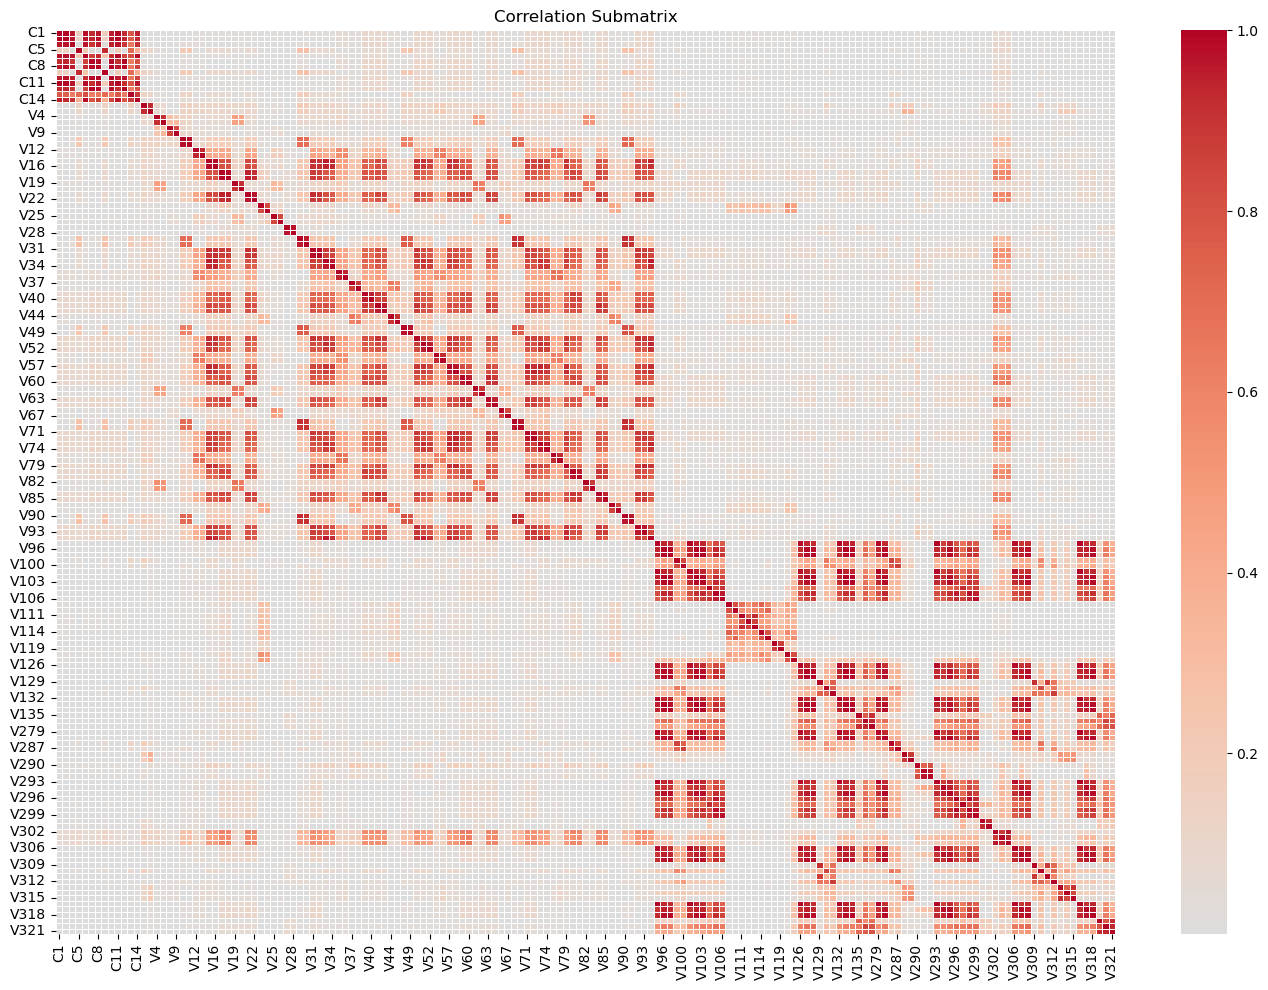

163 correlated features


In [31]:
# Correlation matrix on training features only (not target)
numerical_cols = numericals_train.columns.tolist() # Get labels
corr = X_train_encoded[numerical_cols].corr().abs()  # Absolute values

# Filter first because we have too many columns (unreadable otherwise)
# Only show features with at least high correlation > 0.8
high_corr_cols = corr.columns[(corr > 0.8).sum() > 1].tolist()
plt.figure(figsize=(14, 10))
sns.heatmap(corr.loc[high_corr_cols, high_corr_cols], fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Correlation Submatrix')
plt.tight_layout()
plt.show()

# Check how many columns would need to be dropped
cols_to_drop = corr.columns[(corr > 0.8).sum() > 1].tolist()
print(f"{len(cols_to_drop)} correlated features")

# Do we drop?
#X_train_encoded = X_train_encoded.drop(columns=cols_to_drop)
#X_test_encoded = X_test_encoded.drop(columns=cols_to_drop)

The V-columns break into clear correlation clusters (the dark red blocks along the diagonal). This tells us groups of V-features are strongly tied to each other. For instance, V16–V93 form one block, while V96-V318 form another. These are essentially Vesta feature groups (different variations or transformations of the same underlying signal). It would be helpful to work through them and infer meaning in the EDA notebook first.

Same idea with C1, C5, C8, C11, C14. They sit in that top-left dark red cluster. These are the count based features, like number of addresses linked to a card (check EDA), so naturally they move together and measure very similar behavior.

For a Decision Tree, this isn’t really an issue. It’ll just pick whichever feature in the group gives the best split. It does confirm a lot of the V-features are redundant, so we can shrink the feature space and keep a representative from each cluster if needed.

In [11]:
# Standardize the features
# For K-Means, unscaled features would dominate the clustering
# Centers data around mean=0 with std=1 and preserves the variability of the features
scaler = StandardScaler()
X_train_standardized = pd.DataFrame(scaler.fit_transform(X_train_encoded), columns=X_train_encoded.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_encoded), columns=X_test_encoded.columns) # For final evaluation

In [12]:
# Normalize the features to the range [0, 1]
# Can squish outlier values toward the edges of 0 or 1 (clusters would be harder to separate)
# Might not be ideal to use instead of X_train_standardized
#normalizer = MinMaxScaler()
#X_train_normalized = pd.DataFrame(normalizer.fit_transform(X_train_encoded), columns=X_train_encoded.columns)
#X_test_normalized = pd.DataFrame(normalizer.transform(X_test_encoded), columns=X_test_encoded.columns)

#### Splitting the data

In [14]:
# Split before SMOTE to avoid a data leakage
# Forgot to do that before SMOTE and got suspicious numbers
X_train_split, X_test, y_train_split, y_test = train_test_split(X_train_standardized, y_train, test_size=0.2, random_state=42, stratify=y_train)

#### SMOTE

In [15]:
# Apply SMOTE on train_split
smote = SMOTE(random_state=42, k_neighbors=5) # Default settings
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_split, y_train_split)

In [16]:
X_train_resampled.head()

,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,C1,C2,...,P_emaildomain_yahoo.de,P_emaildomain_yahoo.es,P_emaildomain_yahoo.fr,P_emaildomain_ymail.com,M1_T,M2_T,M3_T,M4_M1,M4_M2,M6_T
0,-1.378280,-0.146458,-0.759357,0.232881,-0.281425,-1.202005,-0.288210,0.069833,-0.09802,-0.092260,...,-0.011195,-0.015065,-0.015563,-0.063827,0.006507,0.247059,0.359867,-0.313436,-0.335871,-0.697637
1,-0.078857,-0.439188,-0.407808,-0.111957,-0.281425,0.595963,-1.549293,0.069833,-0.09802,-0.092260,...,-0.011195,-0.015065,-0.015563,-0.063827,0.006507,0.247059,0.359867,-0.313436,-0.335871,-0.697637
2,-1.148048,-0.113217,0.365477,-1.606256,-0.281425,0.644557,-1.049029,0.069833,-0.09802,-0.092260,...,-0.011195,-0.015065,-0.015563,-0.063827,0.006507,0.247059,0.359867,-0.313436,-0.335871,1.433410
3,1.283768,0.447072,-1.485919,-0.226903,-0.281425,-2.368254,0.399654,0.069833,-0.09802,-0.085795,...,-0.011195,-0.015065,-0.015563,-0.063827,0.006507,0.247059,-2.778801,-0.313436,-0.335871,1.433410
4,-0.641085,-0.075376,0.791907,-0.412094,-0.281425,0.644557,1.556515,0.069833,-0.09802,-0.092260,...,-0.011195,-0.015065,-0.015563,-0.063827,0.006507,0.247059,0.359867,-0.313436,-0.335871,-0.697637


In [17]:
# Sanity check on target variable
print("Before SMOTE:")
print(y_train.value_counts())

print("After SMOTE:")
print(y_train_resampled.value_counts())

print("NA count:")
print(f"NAs in train: {X_train_resampled.isna().sum().sum()}")
print(f"NAs in test: {X_test_scaled.isna().sum().sum()}")

Before SMOTE:
isFraud
0    569877
1     20663
Name: count, dtype: int64
After SMOTE:
isFraud
0    455902
1    455902
Name: count, dtype: int64
NA count:
NAs in train: 0
NAs in test: 0


#### Association Rules

This was actually a horrible idea please disregard unless it can be salvaged. I thought it would be a potentially decent pre-processing step to engineer new binary features from categorical transaction attributes. The goal was to identify co-occurring combinations of categorical values (like card type, product code, and device information) that frequently appear together, and use these patterns as additional features for the Decision Tree classifier (to make it stronger). It took awhile and it was computationally infeasible at first. Even after tweaking it, it required a lot of memory. After sampling and restricting itemset length, the 83 columns turned into 224.

In [18]:
from mlxtend.frequent_patterns import apriori, association_rules

# Convert transaction data to a format suitable for association rule mining (One-hot encoding)
basket = pd.get_dummies(X_train_imputed[categoricals_train.columns])
basket_sample = basket.sample(n=10000, random_state=42) # Use a sample

min_support = 0.05
min_confidence = 0.7

# Perform Apriori algorithm to find frequent itemsets
frequent_itemsets = apriori(basket_sample, min_support=min_support, use_colnames=True, max_len=2)

# Generate association rules with the given confidence threshold
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_confidence)

# Show the resulting rules EATS UP MEMORY
#print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

In [19]:
print(basket.shape)  # If columns are in the thousands, BIG PROBLEM

(590540, 83)


### Modelling

For fraud detection, missing a fraudulent transaction (FN) is far worse than a false alarm. Is our pipeline good enough? I feel like something is off for some reason. Maybe I did not do the V-features justice.

#### Decision Tree

In [20]:
clf = DecisionTreeClassifier(
    criterion='entropy', 
    random_state=67, 
    class_weight='balanced',
    max_depth=10, # Can be tuned later (be mindful of overfitting)
    min_samples_leaf=50,
    )

clf.fit(X_train_split, y_train_split)
clf_pred = clf.predict(X_test)

print(classification_report(y_test, clf_pred))

              precision    recall  f1-score   support

           0       0.99      0.87      0.92    113975
           1       0.17      0.75      0.27      4133

    accuracy                           0.86    118108
   macro avg       0.58      0.81      0.60    118108
weighted avg       0.96      0.86      0.90    118108



In [21]:
clf_smote = DecisionTreeClassifier(
    criterion='entropy', 
    random_state=67,
    class_weight='balanced',
    max_depth=10, # Can be tuned later (be mindful of overfitting)
    min_samples_leaf=50,
    )

clf_smote.fit(X_train_resampled, y_train_resampled)
clf_pred_smote = clf.predict(X_test)

print(classification_report(y_test, clf_pred_smote))

              precision    recall  f1-score   support

           0       0.99      0.87      0.92    113975
           1       0.17      0.75      0.27      4133

    accuracy                           0.86    118108
   macro avg       0.58      0.81      0.60    118108
weighted avg       0.96      0.86      0.90    118108



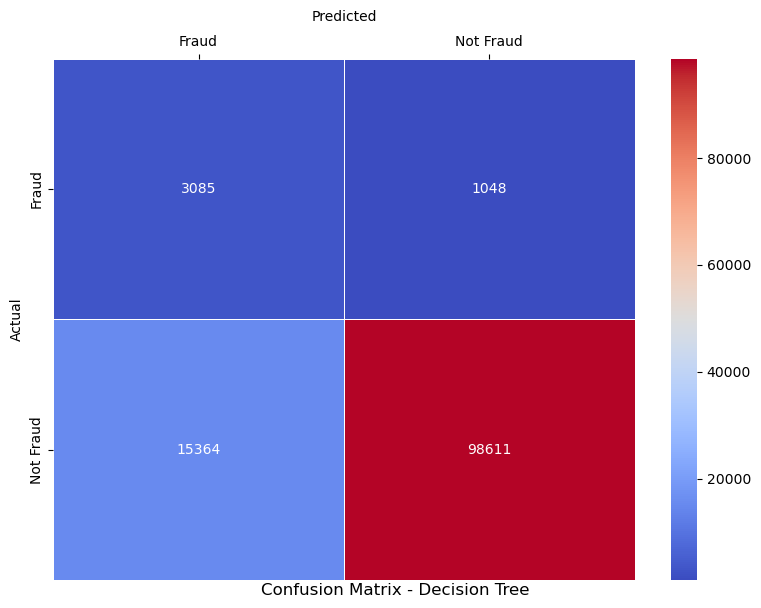

In [22]:
cm_dt = confusion_matrix(y_test, clf_pred, labels=[1, 0])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_dt, cmap='coolwarm', annot=True, fmt='d',
            xticklabels=['Fraud', 'Not Fraud'],
            yticklabels=['Fraud', 'Not Fraud'],
            linewidths=0.5, ax=ax)

ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
ax.set_xlabel('Predicted', labelpad=10)
ax.set_ylabel('Actual')

fig.text(0.5, 0.00, 'Confusion Matrix - Decision Tree', 
         ha='center', fontsize=12)

plt.tight_layout()
plt.show()

#### Random Forest

In [23]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')

rf.fit(X_train_split, y_train_split)
rf_pred = rf.predict(X_test)

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113975
           1       0.93      0.44      0.59      4133

    accuracy                           0.98    118108
   macro avg       0.96      0.72      0.79    118108
weighted avg       0.98      0.98      0.98    118108



- High precision (81%) means there are few false alarms
- Low recall (50%) means the model is missing half the frauds

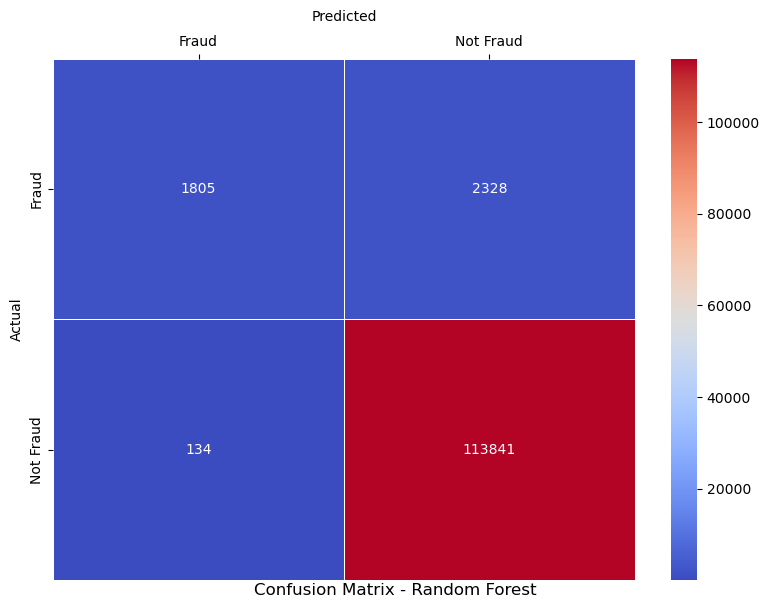

In [24]:
cm_rf = confusion_matrix(y_test, rf_pred, labels=[1, 0])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_rf, cmap='coolwarm', annot=True, fmt='d',
            xticklabels=['Fraud', 'Not Fraud'],
            yticklabels=['Fraud', 'Not Fraud'],
            linewidths=0.5, ax=ax)

ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
ax.set_xlabel('Predicted', labelpad=10)
ax.set_ylabel('Actual')

fig.text(0.5, 0.00, 'Confusion Matrix - Random Forest', 
         ha='center', fontsize=12)

plt.tight_layout()
plt.show()

#### K-Means

Unsupervised method and does not need SMOTE, which makes it ideal to fit on X_train_standardized. K-Means does require scaling or normalization to avoid feature dominance (Eucledian distance).

Text(0, 0.5, 'Inertia (within sum of squares)')

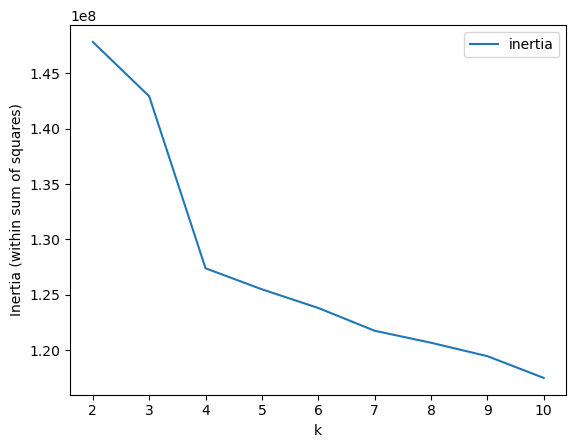

In [25]:
# Find a good K using the Elbow Method
inertia_list = []
k_range = range(2, 11)

for k in k_range:
    model1 = KMeans(n_clusters=k, random_state=42, n_init='auto')
    model1.fit(X_train_standardized)
    inertia_list.append({'k':k, 'inertia':model1.inertia_}) # Compute for each k

# Plot the elbow
ax = pd.DataFrame(inertia_list).set_index('k').plot.line()
ax.set_ylabel('Inertia (within sum of squares)')

Text(0, 0.5, 'Silhouette Score')

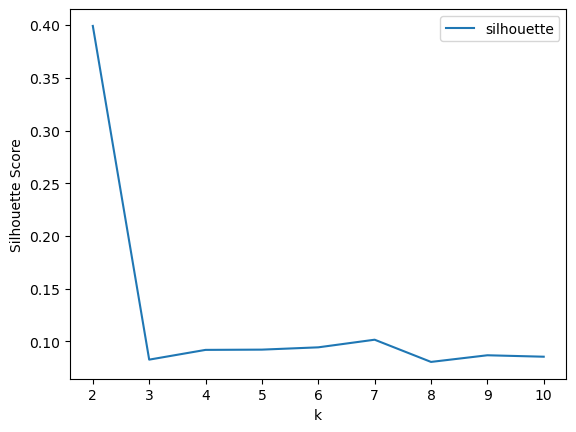

In [26]:
# Plot the silhouette
silhouette_list = []
X_sample = X_train_standardized.sample(n=10000, random_state=42) # Fit on a sample for efficiency

for k in k_range:
    model2 = KMeans(n_clusters=k, random_state=42, n_init='auto')
    model2.fit(X_train_standardized)  # Fit on full data
    labels = model2.predict(X_sample)  # Score on sample only
    score = silhouette_score(X_sample, labels)
    silhouette_list.append({'k': k, 'silhouette': score})

ax = pd.DataFrame(silhouette_list).set_index('k').plot.line()
ax.set_ylabel('Silhouette Score')

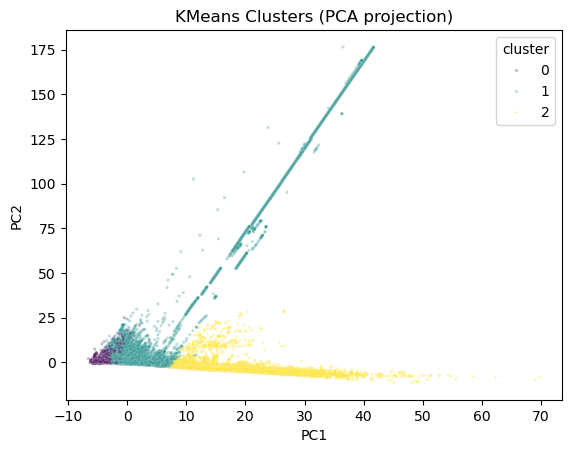

In [27]:
# k=3 based on elbow method
model_final = KMeans(n_clusters=3, random_state=42)
model_final.fit(X_train_standardized)
assignments = pd.Series(model_final.predict(X_train_standardized))

# PCA for visualization
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_standardized)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['cluster'] = assignments.values

ax = sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='cluster', palette='viridis', alpha=0.3, s=5)
ax.set_title('KMeans Clusters (PCA projection)')
plt.show()

Detecting outliers and anomolies like outlined in our proposal, rather than detecting fraud. The combination of K-Means and Random Forest (or a Decision Tree) can be robust enough to detect outliers first than predict future fraudulent transactions.

#### Frequent Itemset Mining